<div style="border-left:6px solid #ae0000; padding:6px 20px; margin-bottom:4px;">
<h1 style="margin:0; color:#0d2741;">Tipos de Variables y Exploración de Datos con pandas</h1>
<p style="margin:6px 0 0 0; color:#444; font-size:1.1em;"><em>Estadística Computacional para la Toma de Decisiones</em></p>
</div>

**Magíster en Ciencia de Datos e Inteligencia Artificial** · Universidad Andrés Bello  
Maidana, J.P. (2026)

---

> **Cómo usar este notebook.** Ejecuta las celdas en orden (de arriba hacia abajo). Las celdas de código son auto-contenidas dentro de cada ejemplo y reproducen exactamente el material del apunte. Comienza ejecutando la celda **«Preparación del entorno»** que aparece a continuación.

## Preparación del entorno

In [1]:
# Librerías usadas a lo largo del notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Mantiene la salida limpia en pandas >= 3.0 (las columnas de texto pasaron de
# 'object' a 'str'; el selector include='object' sigue funcionando pero avisa).
import warnings
warnings.filterwarnings('ignore', message=".*'str' dtypes are included.*")

print("pandas:", pd.__version__)
print("numpy :", np.__version__)

pandas: 2.3.3
numpy : 2.3.5


<div style="background-color:#fffceb; border-left:5px solid #f9a825; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#f57f17; font-size:1.05em;">📝&nbsp; Nota — Compatibilidad de versiones de pandas</p>
<ul style="margin:0;">
<li>Este apunte fue escrito asumiendo <strong>pandas 2.x</strong>, donde las columnas de texto se cargan con dtype <code>object</code> y las fechas como <code>datetime64[ns]</code>. Las «salidas esperadas» que aparecen más abajo reflejan ese comportamiento.</li>
<li>Si trabajas con <strong>pandas ≥ 3.0</strong> verás dos diferencias menores y sin impacto conceptual: las columnas de texto aparecen como <code>str</code> en vez de <code>object</code>, y las fechas como <code>datetime64[us]</code> en vez de <code>[ns]</code>.</li>
<li>La frecuencia horaria de <code>pd.date_range</code> se escribe <code>freq='h'</code> (minúscula). La forma antigua <code>'H'</code> fue eliminada en pandas 3.0.</li>
</ul>
</div>

## 1. Introducción

Una fuente frecuente de errores en proyectos de análisis de datos es la falta de claridad sobre el tipo de variable que se está trabajando. Aplicar regresión lineal a códigos postales, calcular el promedio de identificadores de producto o tratar una escala ordinal como si fuera continua son errores que generan conclusiones sin validez estadística, independientemente de la sofisticación del algoritmo empleado.

La clasificación de variables —cualitativas o cuantitativas, nominales u ordinales, discretas o continuas— no es un requisito formal. Es el fundamento que determina qué métodos estadísticos son válidos, qué visualizaciones son informativas, qué algoritmos de *machine learning* son aplicables y cómo deben validarse los datos. Esta clasificación debe resolverse **antes** de cualquier otro paso del análisis.

Para implementar estas tareas en Python, **pandas** es la herramienta estándar del sector. Fue creada por Wes McKinney en 2008 y se ha consolidado como la librería de referencia para manipulación y exploración de datos. Su diseño está orientado a la realidad de los datos en producción: columnas con tipos mixtos, valores faltantes, fechas en distintos formatos y categorías con inconsistencias. Este apunte cubre los fundamentos conceptuales de la clasificación de variables y su implementación práctica con pandas.

<div style="background-color:#fffceb; border-left:5px solid #f9a825; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#f57f17; font-size:1.05em;">📝&nbsp; Nota — Objetivos de aprendizaje</p>
<ol style="margin:0;">
<li>Distinguir entre variables cualitativas y cuantitativas.</li>
<li>Identificar los subtipos (nominales, ordinales, discretas, continuas).</li>
<li>Utilizar pandas para explorar y validar datasets.</li>
<li>Optimizar el uso de memoria mediante la elección correcta de tipos de datos.</li>
<li>Aplicar un flujo de trabajo sistemático de exploración de datos.</li>
</ol>
</div>

## 2. Clasificación de Variables

### 2.1 Relevancia de la Clasificación

La clasificación de variables no es un ejercicio académico. Cada tipo de variable determina con precisión:

- Qué **métodos estadísticos** pueden aplicarse (no todos son válidos con todos los tipos).
- Qué **visualizaciones** son informativas (un histograma de una variable nominal no tiene interpretación).
- Qué **algoritmos de machine learning** son apropiados.
- Qué **transformaciones** son matemáticamente válidas.
- Cómo **detectar errores** en los datos (rangos imposibles, categorías inesperadas).

El software ejecutará cualquier operación que se le indique, aunque el resultado carezca de sentido. El analista es quien debe saber qué operaciones son válidas para cada tipo de variable.

<div style="background-color:#e8f1fb; border-left:5px solid #1565c0; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#0d47a1; font-size:1.05em;">📘&nbsp; Definición — Variables Cualitativas (Categóricas)</p>
<p style="margin:0 0 8px 0;">Las variables cualitativas describen cualidades o atributos. Aunque en ocasiones se codifican con números, no representan cantidades en sentido matemático.</p>
<p style="margin:0 0 8px 0;"><strong>Nominales:</strong> sin orden natural entre sus categorías. Ejemplos: color, país, tipo de producto, marca. Se pueden contar y calcular frecuencias o la moda, pero no tiene sentido calcular un promedio ni establecer una relación de mayor/menor.</p>
<p style="margin:0 0 8px 0;"><strong>Ordinales:</strong> con un orden lógico definido, pero sin distancias precisas entre categorías. Ejemplos: nivel educativo (primaria &lt; secundaria &lt; universitaria), satisfacción del cliente (bajo, medio, alto), nivel socioeconómico. Se pueden calcular medianas y establecer comparaciones de orden, pero las diferencias entre categorías no son necesariamente iguales.</p>
<p style="margin:0;"><strong>Características fundamentales:</strong></p>
<ul style="margin:4px 0 0 0;">
<li>Representan categorías, no cantidades.</li>
<li>Las operaciones de suma o multiplicación no tienen interpretación válida.</li>
<li>Siempre es posible comparar si dos valores son iguales.</li>
<li>Para ordinales, además se puede determinar cuál es «mayor».</li>
</ul>
</div>

<div style="background-color:#e8f1fb; border-left:5px solid #1565c0; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#0d47a1; font-size:1.05em;">📘&nbsp; Definición — Variables Cuantitativas (Numéricas)</p>
<p style="margin:0 0 8px 0;">Las variables cuantitativas representan cantidades. Las operaciones aritméticas tienen interpretación directa.</p>
<p style="margin:0 0 8px 0;"><strong>Discretas:</strong> toman valores contables, generalmente enteros. Ejemplos: número de clientes, cantidad de transacciones, unidades vendidas. No es posible tener 2.5 clientes. Cuando el rango de valores es muy amplio (ej. ventas diarias entre 0 y 10.000), en la práctica pueden tratarse como continuas para ciertos análisis.</p>
<p style="margin:0 0 8px 0;"><strong>Continuas:</strong> pueden tomar cualquier valor dentro de un rango. Ejemplos: temperatura (23,5 °C, 23,51 °C…), precio, tiempo, distancia. En teoría, entre dos valores siempre existe otro. En la práctica, las computadoras las almacenan con precisión finita (<code>float64</code> típicamente), pero conceptualmente son continuas.</p>
<p style="margin:0;"><strong>Características fundamentales:</strong></p>
<ul style="margin:4px 0 0 0;">
<li>Representan cantidades numéricas reales.</li>
<li>Todas las operaciones aritméticas tienen sentido.</li>
<li>Se pueden calcular promedio, desviación estándar y correlaciones.</li>
<li>Para variables continuas, entre dos valores siempre existe otro (teóricamente).</li>
</ul>
</div>

### 2.2 Diagrama de Clasificación

El siguiente diagrama resume la taxonomía completa. Está generado con `matplotlib`, de modo que puedes ejecutarlo y modificarlo.

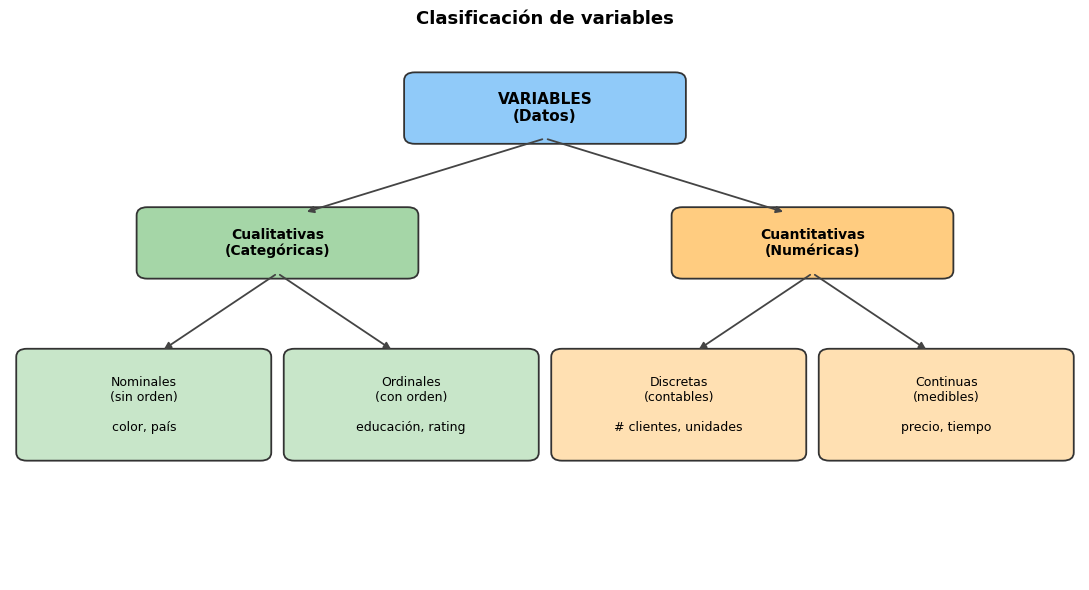

In [2]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 12); ax.set_ylim(0, 8); ax.axis('off')

def _box(x, y, w, h, text, fc, fs=10, fw='normal'):
    ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h,
                 boxstyle="round,pad=0.08,rounding_size=0.12",
                 fc=fc, ec='#333333', lw=1.3))
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, fontweight=fw)

def _arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color='#444', lw=1.3))

# Raíz
_box(6, 7, 3.0, 0.9, "VARIABLES\n(Datos)", '#90caf9', 11, 'bold')
# Nivel 1
_box(3, 5, 3.0, 0.9, "Cualitativas\n(Categóricas)", '#a5d6a7', 10, 'bold')
_box(9, 5, 3.0, 0.9, "Cuantitativas\n(Numéricas)", '#ffcc80', 10, 'bold')
_arrow(6, 6.55, 3.3, 5.45); _arrow(6, 6.55, 8.7, 5.45)
# Nivel 2
_box(1.5,  2.6, 2.7, 1.5, "Nominales\n(sin orden)\n\ncolor, país",        '#c8e6c9', 9)
_box(4.5,  2.6, 2.7, 1.5, "Ordinales\n(con orden)\n\neducación, rating",  '#c8e6c9', 9)
_box(7.5,  2.6, 2.7, 1.5, "Discretas\n(contables)\n\n# clientes, unidades", '#ffe0b2', 9)
_box(10.5, 2.6, 2.7, 1.5, "Continuas\n(medibles)\n\nprecio, tiempo",       '#ffe0b2', 9)
_arrow(3, 4.55, 1.7, 3.4); _arrow(3, 4.55, 4.3, 3.4)
_arrow(9, 4.55, 7.7, 3.4); _arrow(9, 4.55, 10.3, 3.4)

plt.title("Clasificación de variables", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 2.3 Variables Numéricamente Codificadas que No son Cuantitativas

Un error frecuente consiste en tratar como cuantitativa cualquier variable que contiene números. La **regla práctica** es simple: si calcular el promedio de la variable no tiene sentido en el contexto real, probablemente sea categórica aunque esté codificada con números.

<div style="background-color:#fdecea; border-left:5px solid #c62828; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#b71c1c; font-size:1.05em;">⚠️&nbsp; Advertencia — Variables que frecuentemente se clasifican de forma incorrecta</p>
<p style="margin:0 0 8px 0;"><strong>Código postal:</strong> no tiene sentido calcular el promedio de códigos postales, ni afirmar que el código 28001 es «mayor» que el 08001. Son etiquetas identificadoras codificadas con dígitos. <em>Tipo correcto: categórica nominal.</em></p>
<p style="margin:0 0 8px 0;"><strong>IDs de productos:</strong> un identificador numérico no representa magnitud alguna. <em>Tipo correcto: categórica nominal.</em></p>
<p style="margin:0 0 8px 0;"><strong>Año de graduación:</strong> depende del uso. Para analizar tendencias temporales, es cuantitativa. Para agrupar por cohortes («generación 2010»), es categórica ordinal. El contexto determina el tipo.</p>
<p style="margin:0 0 8px 0;"><strong>Calificaciones con estrellas (1–5):</strong> técnicamente son ordinales. Hay orden definido, pero la distancia psicológica entre 1 y 2 estrellas no es necesariamente igual a la distancia entre 4 y 5. En muchos análisis se tratan como cuantitativas por conveniencia; esta simplificación es aceptable siempre que se reconozca explícitamente.</p>
<p style="margin:0;"><strong>Mes del año (1–12):</strong> variable ordinal con la particularidad de ser cíclica (después del mes 12 viene el 1). El promedio aritmético de enero (1) y diciembre (12) no produce un resultado interpretable.</p>
</div>

| Variable | ¿Parece numérica? | Tipo correcto |
|---|---|---|
| Código postal | Sí | Categórica nominal |
| Calificación 1–5 estrellas | Sí | Categórica ordinal |
| Temperatura en °C | Sí | Cuantitativa continua |
| Número de hijos | Sí | Cuantitativa discreta |
| Mes del año (1–12) | Sí | Categórica ordinal (cíclica) |

<div align="center"><em>Tabla 2.1 — Variables de clasificación no evidente.</em></div>

### 2.4 Operaciones Válidas por Tipo

| Tipo | Valores | Operaciones válidas | Estadísticos | Gráficos |
|---|---|---|---|---|
| **Nominal** | Categorías sin orden | Frecuencia, moda | Moda, proporción | Barras, torta |
| **Ordinal** | Categorías con orden | Frecuencia, orden, mediana | Moda, mediana, rango | Barras ordenadas |
| **Discreta** | Enteros | Todas las aritméticas | Media, mediana, varianza | Histograma, barras |
| **Continua** | Reales | Todas las aritméticas | Media, desv. est., percentiles | Histograma, densidad, boxplot |

<div align="center"><em>Tabla 2.2 — Operaciones válidas y estadísticos disponibles según tipo de variable.</em></div>

## 3. Tipos de Datos en pandas

### 3.1 El Sistema de Tipos (dtypes)

pandas implementa su propio sistema de tipos, heredado en parte de NumPy. La terminología difiere de la clasificación estadística vista anteriormente, pero la correspondencia es directa.

| dtype pandas | Tipo de variable | Cuándo usar |
|---|---|---|
| `int64, int32, int16` | Discreta | Enteros con signo. `int64` es el tipo por defecto; usar `int32`/`int16` cuando el rango lo permita para reducir memoria. |
| `uint64, uint32, uint16` | Discreta | Enteros sin signo (solo positivos). Adecuado para conteos. |
| `float64, float32` | Continua | Valores decimales. `float64` por defecto; usar `float32` cuando se requiera reducir memoria y la precisión lo permita. |
| `object` | Nominal | Cadenas de texto o tipos mixtos. Funcional pero ineficiente en memoria. Preferir `category`. |
| `category` | Nominal u ordinal | Tipo optimizado para variables categóricas. Reduce memoria y acelera agrupaciones. |
| `bool` | Binaria | Valores True/False. Muy eficiente (1 byte por valor). |
| `datetime64[ns]` | Temporal | Fechas y horas con precisión de nanosegundos. |
| `timedelta64[ns]` | Duración | Diferencias entre fechas/horas. |
| `string` | Nominal | Tipo dedicado para cadenas (desde pandas 1.0), más eficiente que `object`. |

<div align="center"><em>Tabla 3.1 — Tipos de datos (dtypes) de pandas y su correspondencia.</em></div>

### 3.2 `object` vs `category`

<div style="background-color:#fff4e6; border-left:5px solid #e65100; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#bf360c; font-size:1.05em;">⭐&nbsp; Importante — Por qué usar <code>category</code> en lugar de <code>object</code></p>
<p style="margin:0 0 8px 0;">Consideremos una columna «país» con 1.000.000 de filas y solo 10 valores únicos.</p>
<p style="margin:0 0 8px 0;"><strong>Con <code>object</code>:</strong> pandas almacena la cadena completa en cada fila. El string «Argentina» se guarda 1.000.000 de veces. Alto consumo de memoria.</p>
<p style="margin:0 0 8px 0;"><strong>Con <code>category</code>:</strong> pandas almacena los 10 valores únicos una sola vez y en cada fila solo guarda un código entero (0–9) que referencia al valor. La reducción de memoria puede alcanzar el 90%.</p>
<p style="margin:0 0 8px 0;">Adicionalmente, operaciones como <code>groupby</code> son significativamente más rápidas sobre columnas <code>category</code>.</p>
<p style="margin:0 0 8px 0;"><strong>Criterio práctico:</strong> si una columna tiene menos del 50% de valores únicos respecto al total de filas, conviene convertirla a <code>category</code>.</p>
<p style="margin:0;"><strong>Para variables ordinales:</strong> se puede especificar <code>ordered=True</code> al crear el tipo <code>category</code>, lo que permite respetar el orden definido en operaciones de ordenamiento y comparación.</p>
</div>

| Característica | `object` | `category` |
|---|---|---|
| Uso de memoria | Alto (guarda strings completos) | Bajo (códigos + diccionario) |
| Velocidad en groupby | Lenta | Rápida |
| Orden preservado | No | Sí (opcional) |
| Métodos especiales | No | Sí (acceso con `.cat`) |
| Mejor caso de uso | IDs únicos, texto irrepetible | Columnas con valores repetidos |

<div align="center"><em>Tabla 3.2 — Comparación entre los tipos <code>object</code> y <code>category</code>.</em></div>

### 3.3 Tamaños de Tipos y Optimización de Memoria

Al trabajar con conjuntos de datos de gran volumen, la elección del tipo entero o flotante adecuado puede reducir sustancialmente el consumo de memoria.

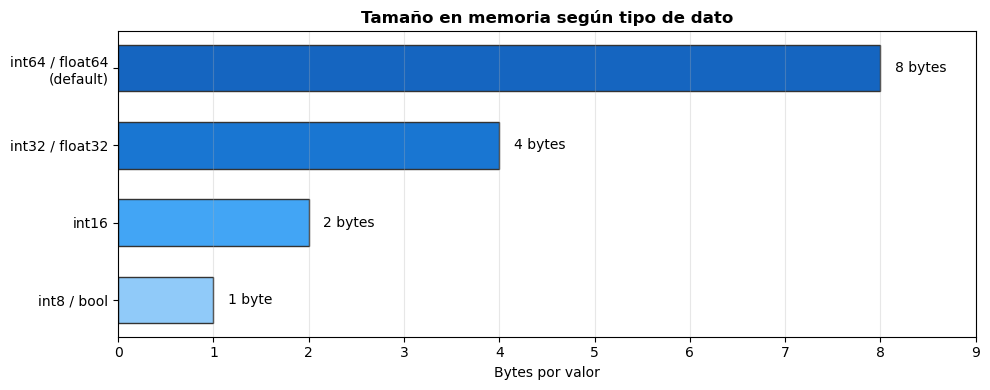

In [3]:
tipos   = ['int64 / float64\n(default)', 'int32 / float32', 'int16', 'int8 / bool']
bytes_  = [8, 4, 2, 1]
colores = ['#1565c0', '#1976d2', '#42a5f5', '#90caf9']

fig, ax = plt.subplots(figsize=(10, 4))
barras = ax.barh(tipos, bytes_, color=colores, edgecolor='#333', height=0.6)
ax.invert_yaxis()
ax.set_xlabel('Bytes por valor')
ax.set_title('Tamaño en memoria según tipo de dato', fontweight='bold')
ax.set_xlim(0, 9)
for b, v in zip(barras, bytes_):
    ax.text(v + 0.15, b.get_y() + b.get_height()/2,
            f'{v} byte' + ('s' if v > 1 else ''), va='center', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Como referencia: una columna de edad (rango 0–120) **no** requiere `int64`. Con `int8` (rango 0–255, ó −128 a 127) es suficiente, lo que representa un ahorro del **87,5%** de memoria en esa columna. En conjuntos de datos de millones de filas, este tipo de ajuste tiene impacto práctico.

## 4. Exploración de Datos con pandas

### 4.1 Los Tres Comandos Fundamentales

Al comenzar el análisis de cualquier nuevo conjunto de datos, los siguientes tres comandos deben ejecutarse sistemáticamente.

<div style="background-color:#e8f1fb; border-left:5px solid #1565c0; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#0d47a1; font-size:1.05em;">📘&nbsp; Definición — El método <code>.info()</code> — vista general del DataFrame</p>
<p style="margin:0 0 6px 0;">Proporciona una visión completa del DataFrame con bajo costo computacional.</p>
<p style="margin:0;"><strong>Información que entrega:</strong></p>
<ul style="margin:4px 0 8px 0;">
<li>Dimensiones (filas y columnas).</li>
<li>Nombre de cada columna.</li>
<li>Tipo de dato de cada columna.</li>
<li>Cantidad de valores no nulos (permite detectar valores faltantes).</li>
<li>Consumo aproximado de memoria.</li>
</ul>
<p style="margin:0;"><strong>Parámetros relevantes:</strong></p>
<ul style="margin:4px 0 8px 0;">
<li><code>memory_usage='deep'</code>: calcula el consumo real de memoria en lugar de una aproximación.</li>
<li><code>verbose=False</code>: muestra solo el resumen sin el detalle por columna.</li>
</ul>
<p style="margin:0;">Una columna con 100.000 filas y 95.000 valores no nulos indica 5.000 faltantes. Identificar la causa debe ser prioridad antes de continuar.</p>
</div>

<div style="background-color:#e8f1fb; border-left:5px solid #1565c0; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#0d47a1; font-size:1.05em;">📘&nbsp; Definición — El método <code>.describe()</code> — estadísticos descriptivos</p>
<p style="margin:0 0 6px 0;">Genera estadísticos descriptivos y adapta su salida al tipo de dato de cada columna.</p>
<p style="margin:0;"><strong>Para variables numéricas (por defecto):</strong> <code>count</code>, <code>mean</code>, <code>std</code>, <code>min</code>, <code>max</code>, y los cuartiles <code>25%</code>, <code>50%</code>, <code>75%</code>.</p>
<p style="margin:6px 0 0 0;"><strong>Para variables categóricas</strong> (con <code>include='all'</code> o <code>include='object'</code>): <code>count</code>, <code>unique</code> (valores distintos), <code>top</code> (moda) y <code>freq</code> (frecuencia del más común).</p>
<p style="margin:6px 0 0 0;"><strong>Parámetros relevantes:</strong> <code>include='all'</code> incluye todas las columnas; <code>percentiles=[.1, .5, .9]</code> permite especificar percentiles.</p>
<p style="margin:6px 0 0 0;">Valores mínimos o máximos fuera de rango lógico (ej. edad = −5 o edad = 200) son indicadores inmediatos de problemas de calidad.</p>
</div>

<div style="background-color:#e8f1fb; border-left:5px solid #1565c0; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#0d47a1; font-size:1.05em;">📘&nbsp; Definición — La propiedad <code>.dtypes</code> — verificación de tipos</p>
<p style="margin:0 0 6px 0;">Es una <strong>propiedad</strong> (no un método; no requiere paréntesis). Devuelve una Serie con el tipo de dato de cada columna.</p>
<p style="margin:0;"><strong>Usos principales:</strong></p>
<ul style="margin:4px 0 8px 0;">
<li>Verificar que pandas interpretó correctamente los tipos al cargar los datos.</li>
<li>Identificar columnas que requieren conversión de tipo.</li>
<li>Confirmar que las transformaciones produjeron el resultado esperado.</li>
</ul>
<p style="margin:0;"><strong>Métodos relacionados:</strong> <code>.select_dtypes(include=['int64','float64'])</code> selecciona columnas por tipo; <code>.astype('category')</code> convierte una columna.</p>
<p style="margin:6px 0 0 0;">Caso típico: al cargar un CSV, <code>codigo_postal</code> aparece como <code>int64</code>. Como es un identificador y no una cantidad, debe convertirse a <code>object</code>/<code>category</code> antes de cualquier análisis.</p>
</div>

### 4.2 Comandos Complementarios

| Comando | Descripción |
|---|---|
| `.head(n=5)` | Primeras *n* filas. Útil para verificar el formato. |
| `.tail(n=5)` | Últimas *n* filas. |
| `.sample(n=10)` | *n* filas aleatorias. Preferible a `head` para una exploración representativa. |
| `.shape` | Dimensiones como tupla (filas, columnas). |
| `.columns` | Lista de nombres de columnas. |
| `.nunique()` | Número de valores únicos por columna. |
| `.isnull().sum()` | Cuenta de valores faltantes por columna. |
| `.value_counts()` | Frecuencia de cada valor en una Serie. |
| `.memory_usage(deep=True)` | Consumo de memoria por columna. |

<div align="center"><em>Tabla 4.1 — Comandos de uso frecuente en exploración de datos.</em></div>

### 4.3 Flujo de Trabajo de Exploración

El siguiente flujo sistematiza la exploración inicial de cualquier conjunto de datos. La Sección 5 (Ejemplo 3) lo implementa de principio a fin.

1. **Cargar** los datos con `pd.read_csv()` (especificar `dtype` si es posible).
2. **`df.info()`** — identificar tipos y valores nulos.
3. **`df.head()`** — inspeccionar las primeras filas.
4. **`df.dtypes`** — verificar la coherencia de los tipos.
5. ¿Tipos correctos? → si **no**, convertir con `astype()` / `pd.to_datetime()` y volver al paso 4.
6. **`df.describe(include='all')`** — analizar distribuciones.
7. **`df.isnull().sum()`** — detectar valores faltantes.
8. **Optimizar** tipos (`downcast`, `category`).
9. **Visualizar** — exploración gráfica.

## 5. Implementación: Ejemplos con Código

### 5.1 Ejemplo 1 — Dataset Básico de E-commerce

In [4]:
import pandas as pd
import numpy as np

datos = {
    'producto_id':       [101, 102, 103, 104, 105],
    'categoria':         ['Electronica', 'Ropa', 'Electronica', 'Hogar', 'Ropa'],
    'precio':            [299.99, 49.99, 899.99, 129.50, 79.99],
    'unidades_vendidas': [45, 230, 12, 78, 156],
    'valoracion':        ['Excelente', 'Bueno', 'Excelente', 'Regular', 'Bueno']
}

df = pd.DataFrame(datos)

# Paso 1: Vista general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   producto_id        5 non-null      int64  
 1   categoria          5 non-null      object 
 2   precio             5 non-null      float64
 3   unidades_vendidas  5 non-null      int64  
 4   valoracion         5 non-null      object 
dtypes: float64(1), int64(2), object(2)
memory usage: 332.0+ bytes


**Salida esperada** (pandas 2.x):

```text
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   producto_id        5 non-null      int64  
 1   categoria          5 non-null      object 
 2   precio             5 non-null      float64
 3   unidades_vendidas  5 non-null      int64  
 4   valoracion         5 non-null      object 
dtypes: float64(1), int64(2), object(2)
memory usage: 332.0+ bytes
```

<div style="background-color:#fffceb; border-left:5px solid #f9a825; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#f57f17; font-size:1.05em;">📝&nbsp; Nota — Observaciones sobre esta salida</p>
<code>producto_id</code> aparece como <code>int64</code>, pero es un identificador sin significado cuantitativo y debería convertirse a <code>object</code>. Las columnas <code>categoria</code> y <code>valoracion</code> se importaron como texto; al tener pocos valores únicos, se beneficiarían de la conversión a <code>category</code>. El símbolo <code>+</code> en el consumo de memoria indica que la estimación no incluye el tamaño real de las cadenas de texto.
</div>

In [5]:
# Paso 2: Ver tipos actuales
print(df.dtypes)

producto_id            int64
categoria             object
precio               float64
unidades_vendidas      int64
valoracion            object
dtype: object


In [6]:
# Paso 3: Estadísticos descriptivos
print("Variables numéricas:")
print(df.describe())

print("\nVariables categóricas:")
print(df.describe(include='object'))

Variables numéricas:
       producto_id      precio  unidades_vendidas
count     5.000000    5.000000           5.000000
mean    103.000000  291.892000         104.200000
std       1.581139  353.425718          88.318741
min     101.000000   49.990000          12.000000
25%     102.000000   79.990000          45.000000
50%     103.000000  129.500000          78.000000
75%     104.000000  299.990000         156.000000
max     105.000000  899.990000         230.000000

Variables categóricas:
          categoria valoracion
count             5          5
unique            3          3
top     Electronica  Excelente
freq              2          2


In [7]:
# Paso 4: Frecuencias de variables categóricas
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


categoria:
categoria
Electronica    2
Ropa           2
Hogar          1
Name: count, dtype: int64

valoracion:
valoracion
Excelente    2
Bueno        2
Regular      1
Name: count, dtype: int64


### 5.2 Ejemplo 2 — Conversión a Tipos Optimizados

Convertimos las columnas categóricas a `category` (una nominal y una ordinal) y medimos el impacto en memoria. **Esta celda reutiliza el `df` creado en el Ejemplo 1.**

In [8]:
# Memoria antes de la optimización
mem_antes = df.memory_usage(deep=True).sum()
print(f"Memoria inicial: {mem_antes} bytes")
print(df.memory_usage(deep=True))

# Convertir columna nominal a category
df['categoria'] = df['categoria'].astype('category')

# Convertir columna ordinal a category con orden definido
df['valoracion'] = pd.Categorical(
    df['valoracion'],
    categories=['Regular', 'Bueno', 'Excelente'],
    ordered=True
)

# Memoria después de la optimización
mem_despues = df.memory_usage(deep=True).sum()
print(f"\nMemoria optimizada: {mem_despues} bytes")
print(f"Reducción: {(1 - mem_despues/mem_antes)*100:.1f}%")

Memoria inicial: 812 bytes
Index                132
producto_id           40
categoria            280
precio                40
unidades_vendidas     40
valoracion           280
dtype: int64

Memoria optimizada: 813 bytes
Reducción: -0.1%


In [9]:
# Propiedades del tipo category para la variable ordinal
print(f"Categorías de valoracion: {df['valoracion'].cat.categories.tolist()}")
print(f"¿Es ordenada?: {df['valoracion'].cat.ordered}")

print("\nOrdenamiento por valoracion:")
print(df.sort_values('valoracion'))

# Códigos internos (enteros) asignados a cada categoría
print("\nCódigos numéricos internos:")
print(df['valoracion'].cat.codes)

Categorías de valoracion: ['Regular', 'Bueno', 'Excelente']
¿Es ordenada?: True

Ordenamiento por valoracion:
   producto_id    categoria  precio  unidades_vendidas valoracion
3          104        Hogar  129.50                 78    Regular
1          102         Ropa   49.99                230      Bueno
4          105         Ropa   79.99                156      Bueno
0          101  Electronica  299.99                 45  Excelente
2          103  Electronica  899.99                 12  Excelente

Códigos numéricos internos:
0    2
1    1
2    2
3    0
4    1
dtype: int8


<div style="background-color:#fff4e6; border-left:5px solid #e65100; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#bf360c; font-size:1.05em;">⭐&nbsp; Importante — Beneficios concretos del tipo <code>category</code></p>
<ul style="margin:0 0 8px 0;">
<li>Reducción de memoria de hasta 90% en conjuntos de datos grandes.</li>
<li>El orden lógico se preserva para variables ordinales.</li>
<li>Métodos específicos disponibles: <code>.cat.codes</code>, <code>.cat.categories</code>.</li>
<li>Las operaciones de <code>groupby</code> son considerablemente más rápidas.</li>
</ul>
<p style="margin:0;">En un proyecto con 1 millón de filas y 10 columnas categóricas, la diferencia entre usar <code>object</code> y <code>category</code> puede ser la diferencia entre 2 GB y 200 MB de memoria ocupada.</p>
</div>

### 5.3 Ejemplo 3 — Flujo de Trabajo Completo con Dataset Financiero

Este ejemplo genera un dataset sintético de transacciones y aplica el flujo de trabajo completo de la Sección 4.3, paso por paso.

In [10]:
np.random.seed(42)
n = 1000

df_trans = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=n, freq='h'),   # 'h' minúscula (pandas >= 2.2)
    'monto': np.random.lognormal(mean=5, sigma=1.5, size=n),
    'tipo_transaccion': np.random.choice(
        ['Compra', 'Retiro', 'Transferencia', 'Deposito'],
        size=n, p=[0.5, 0.2, 0.2, 0.1]),
    'metodo_pago': np.random.choice(
        ['Tarjeta', 'Efectivo', 'Transferencia'],
        size=n, p=[0.6, 0.25, 0.15]),
    'estado': np.random.choice(
        ['Aprobado', 'Pendiente', 'Rechazado'],
        size=n, p=[0.85, 0.10, 0.05]),
    'cliente_id': np.random.randint(1000, 2000, size=n),
    'sucursal': np.random.choice(
        ['Norte', 'Sur', 'Centro', 'Oriente'], size=n)
})

# PASO 1: Información general
print("=" * 70)
print("PASO 1: INFORMACIÓN GENERAL")
print("=" * 70)
df_trans.info()

PASO 1: INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             1000 non-null   datetime64[ns]
 1   monto             1000 non-null   float64       
 2   tipo_transaccion  1000 non-null   object        
 3   metodo_pago       1000 non-null   object        
 4   estado            1000 non-null   object        
 5   cliente_id        1000 non-null   int32         
 6   sucursal          1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int32(1), object(4)
memory usage: 50.9+ KB


In [11]:
# PASO 2: Primeras filas
print("PASO 2: PRIMERAS FILAS")
print(df_trans.head(5))

PASO 2: PRIMERAS FILAS
                fecha        monto tipo_transaccion metodo_pago    estado  \
0 2024-01-01 00:00:00   312.645897           Compra     Tarjeta  Aprobado   
1 2024-01-01 01:00:00   120.614987           Compra     Tarjeta  Aprobado   
2 2024-01-01 02:00:00   392.106234           Retiro     Tarjeta  Aprobado   
3 2024-01-01 03:00:00  1457.597461    Transferencia     Tarjeta  Aprobado   
4 2024-01-01 04:00:00   104.456419           Compra    Efectivo  Aprobado   

   cliente_id sucursal  
0        1527    Norte  
1        1354      Sur  
2        1558    Norte  
3        1762    Norte  
4        1186   Centro  


In [12]:
# PASO 3: Clasificación por tipo de dato
numericas   = df_trans.select_dtypes(include=['int64', 'float64']).columns
categoricas = df_trans.select_dtypes(include=['object']).columns
temporales  = df_trans.select_dtypes(include=['datetime64']).columns

print("PASO 3: CLASIFICACIÓN DE VARIABLES")
print(f"Numéricas   ({len(numericas)}):  {list(numericas)}")
print(f"Categóricas ({len(categoricas)}): {list(categoricas)}")
print(f"Temporales  ({len(temporales)}):  {list(temporales)}")

PASO 3: CLASIFICACIÓN DE VARIABLES
Numéricas   (1):  ['monto']
Categóricas (4): ['tipo_transaccion', 'metodo_pago', 'estado', 'sucursal']
Temporales  (1):  ['fecha']


In [13]:
# PASO 4: Estadísticos numéricos
print("PASO 4: ESTADÍSTICOS NUMÉRICOS")
print(df_trans[numericas].describe())

PASO 4: ESTADÍSTICOS NUMÉRICOS
              monto
count   1000.000000
mean     488.118389
std     1790.476681
min        1.148089
25%       56.183214
50%      154.153926
75%      392.256528
max    48006.765889


In [14]:
# PASO 5: Estadísticos categóricos
print("PASO 5: ESTADÍSTICOS CATEGÓRICOS")
print(df_trans[categoricas].describe())

PASO 5: ESTADÍSTICOS CATEGÓRICOS
       tipo_transaccion metodo_pago    estado sucursal
count              1000        1000      1000     1000
unique                4           3         3        4
top              Compra     Tarjeta  Aprobado      Sur
freq                485         600       871      271


In [15]:
# PASO 6: Análisis de unicidad de las categóricas
print("PASO 6: ANÁLISIS DE UNICIDAD")
for col in categoricas:
    n_unique = df_trans[col].nunique()
    pct_unique = n_unique / len(df_trans) * 100
    print(f"\n  {col}: {n_unique} valores únicos ({pct_unique:.2f}%)")
    print(df_trans[col].value_counts().to_string())

PASO 6: ANÁLISIS DE UNICIDAD

  tipo_transaccion: 4 valores únicos (0.40%)
tipo_transaccion
Compra           485
Retiro           214
Transferencia    209
Deposito          92

  metodo_pago: 3 valores únicos (0.30%)
metodo_pago
Tarjeta          600
Efectivo         258
Transferencia    142

  estado: 3 valores únicos (0.30%)
estado
Aprobado     871
Pendiente     85
Rechazado     44

  sucursal: 4 valores únicos (0.40%)
sucursal
Sur        271
Oriente    254
Norte      253
Centro     222


In [16]:
# PASO 7: Valores nulos
print("PASO 7: VALORES FALTANTES")
nulos = df_trans.isnull().sum()
if nulos.sum() == 0:
    print("No se detectaron valores nulos.")
else:
    print(nulos[nulos > 0])

PASO 7: VALORES FALTANTES
No se detectaron valores nulos.


In [17]:
# PASO 8: Optimización de memoria
mem_antes = df_trans.memory_usage(deep=True).sum() / 1024**2
print(f"PASO 8: OPTIMIZACIÓN - Memoria inicial: {mem_antes:.4f} MB")

for col in categoricas:
    if df_trans[col].nunique() / len(df_trans) < 0.5:
        df_trans[col] = df_trans[col].astype('category')
        print(f"  '{col}' convertido a category")

if df_trans['cliente_id'].max() < 2_147_483_647:
    df_trans['cliente_id'] = df_trans['cliente_id'].astype('int32')
    print("  'cliente_id' convertido a int32")

mem_despues = df_trans.memory_usage(deep=True).sum() / 1024**2
print(f"  Memoria optimizada: {mem_despues:.4f} MB")
print(f"  Reducción: {(1 - mem_despues/mem_antes)*100:.1f}%")

PASO 8: OPTIMIZACIÓN - Memoria inicial: 0.2338 MB
  'tipo_transaccion' convertido a category
  'metodo_pago' convertido a category
  'estado' convertido a category
  'sucursal' convertido a category
  'cliente_id' convertido a int32
  Memoria optimizada: 0.0243 MB
  Reducción: 89.6%


In [18]:
# PASO 9: Resumen ejecutivo
print("PASO 9: RESUMEN EJECUTIVO")
print(f"Dimensiones:  {df_trans.shape[0]:,} filas x {df_trans.shape[1]} columnas")
print(f"Período:      {df_trans['fecha'].min()} a {df_trans['fecha'].max()}")
print(f"Monto total:  ${df_trans['monto'].sum():,.2f}")
print(f"Monto medio:  ${df_trans['monto'].mean():,.2f}")
aprobadas = (df_trans['estado'] == 'Aprobado').sum()
print(f"Aprobadas:    {aprobadas:,} ({aprobadas/len(df_trans)*100:.1f}%)")

PASO 9: RESUMEN EJECUTIVO
Dimensiones:  1,000 filas x 7 columnas
Período:      2024-01-01 00:00:00 a 2024-02-11 15:00:00
Monto total:  $488,118.39
Monto medio:  $488.12
Aprobadas:    871 (87.1%)


## 6. Aplicaciones por Sector

<div style="background-color:#e9f7ea; border-left:5px solid #2e7d32; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#1b5e20; font-size:1.05em;">✅&nbsp; Ejemplo — Finanzas — Análisis de Portafolios</p>
<p style="margin:0 0 6px 0;"><strong>Discretas:</strong> número de acciones en portafolio, transacciones diarias, activos por sector.</p>
<p style="margin:0 0 6px 0;"><strong>Continuas:</strong> precio de activos, retorno porcentual, volatilidad, beta del portafolio, Value at Risk (VaR).</p>
<p style="margin:0 0 6px 0;"><strong>Ordinales:</strong> calificación crediticia (AAA &gt; AA &gt; A…), nivel de riesgo del cliente (Conservador &lt; Moderado &lt; Agresivo), horizonte de inversión (Corto &lt; Mediano &lt; Largo).</p>
<p style="margin:0 0 6px 0;"><strong>Nominales:</strong> sector industrial, tipo de instrumento (acción, bono, derivado, ETF), mercado de cotización (NYSE, NASDAQ, LSE).</p>
<p style="margin:0;"><em>Nota:</em> la calificación crediticia debe tratarse como ordinal. Si se trata como nominal, se pierde información sobre la jerarquía de riesgo.</p>
</div>

<div style="background-color:#e9f7ea; border-left:5px solid #2e7d32; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#1b5e20; font-size:1.05em;">✅&nbsp; Ejemplo — E-commerce — Comportamiento de Usuarios</p>
<p style="margin:0 0 6px 0;"><strong>Discretas:</strong> productos en carrito, visitas por sesión, clics en productos, reseñas escritas.</p>
<p style="margin:0 0 6px 0;"><strong>Continuas:</strong> tiempo en página (segundos), monto de compra, Customer Lifetime Value (CLV), bounce rate.</p>
<p style="margin:0 0 6px 0;"><strong>Ordinales:</strong> satisfacción (1–5 estrellas), frecuencia de compra (ocasional &lt; regular &lt; frecuente), nivel de membresía (Bronce &lt; Plata &lt; Oro).</p>
<p style="margin:0 0 6px 0;"><strong>Nominales:</strong> categoría de producto, método de pago, dispositivo (Desktop/Mobile/Tablet), canal de adquisición.</p>
<p style="margin:0;"><em>Error frecuente:</em> tratar «frecuencia de compra» como numérica. Es ordinal: la diferencia entre «ocasional» y «regular» no es cuantitativamente igual a la diferencia entre «regular» y «frecuente».</p>
</div>

<div style="background-color:#e9f7ea; border-left:5px solid #2e7d32; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#1b5e20; font-size:1.05em;">✅&nbsp; Ejemplo — Salud — Datos Médicos</p>
<p style="margin:0 0 6px 0;"><strong>Discretas:</strong> consultas médicas por año, dosis de medicamento, días hospitalizados, número de comorbilidades.</p>
<p style="margin:0 0 6px 0;"><strong>Continuas:</strong> presión arterial (mmHg), glucosa (mg/dL), temperatura corporal, IMC, frecuencia cardíaca.</p>
<p style="margin:0 0 6px 0;"><strong>Ordinales:</strong> severidad de síntomas (leve &lt; moderado &lt; grave), estadio de enfermedad (I &lt; II &lt; III &lt; IV), escala de dolor (0–10).</p>
<p style="margin:0 0 6px 0;"><strong>Nominales:</strong> tipo sanguíneo, diagnóstico (códigos CIE-10), alergias conocidas.</p>
<p style="margin:0;"><em>Nota:</em> el estadio de la enfermedad debe modelarse como ordinal con orden explícito. Tratarlo como nominal implica perder información que afecta la capacidad predictiva.</p>
</div>

<div style="background-color:#e9f7ea; border-left:5px solid #2e7d32; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#1b5e20; font-size:1.05em;">✅&nbsp; Ejemplo — Manufactura e IoT — Sensores Industriales</p>
<p style="margin:0 0 6px 0;"><strong>Discretas:</strong> piezas producidas por turno, defectos detectados, ciclos de máquina, alarmas por hora.</p>
<p style="margin:0 0 6px 0;"><strong>Continuas:</strong> temperatura de motor (°C), vibración (Hz, amplitud), presión del sistema (PSI/bar), consumo eléctrico (kWh), velocidad de producción.</p>
<p style="margin:0 0 6px 0;"><strong>Ordinales:</strong> estado de mantenimiento (óptimo &gt; regular &gt; crítico), nivel de calidad (A &gt; B &gt; C &gt; rechazo).</p>
<p style="margin:0 0 6px 0;"><strong>Nominales:</strong> ID de máquina, turno laboral, código de error o alarma.</p>
<p style="margin:0;"><em>Nota:</em> para mantenimiento predictivo, temperatura y vibración deben mantenerse continuas con alta resolución. Una cuantización excesiva reduce la capacidad de detectar anomalías incipientes.</p>
</div>

| Sector | Discretas clave | Continuas clave | Ordinales clave |
|---|---|---|---|
| Finanzas | # transacciones | Precio, retorno, VaR | Rating crediticio |
| E-commerce | Clics, ítems carrito | Tiempo sesión, CLV | Satisfacción, membresía |
| Salud | # consultas, dosis | Presión, glucosa, IMC | Severidad, estadio |
| Manufactura | Piezas, defectos | Temperatura, vibración | Estado maquinaria |

<div align="center"><em>Tabla 6.1 — Variables representativas por tipo y sector de aplicación.</em></div>

## 7. Buenas Prácticas

A continuación, las prácticas recomendadas para exploración y tipado de datos. Para que todos los fragmentos sean **ejecutables**, primero generamos un pequeño dataset de ejemplo y lo guardamos en disco como `datos.csv`.

In [19]:
# Dataset de ejemplo para esta sección (se guarda en el directorio de trabajo)
np.random.seed(7)
m = 500

ejemplo = pd.DataFrame({
    'codigo_postal': np.random.choice(['8320000', '7500000', '2520000', '4030000'], m),
    'categoria':     np.random.choice(['A', 'B', 'C', 'D'], m),
    'pais':          np.random.choice(['Chile', 'Argentina', 'Perú', 'Colombia'], m),
    'nivel':         np.random.choice(['Bajo', 'Medio', 'Alto'], m),
    'edad':          np.random.randint(18, 90, m),
    'anio':          np.random.randint(2000, 2025, m),
    'id_cliente':    np.random.randint(10000, 99999, m),
    'temperatura':   np.random.normal(22, 5, m).round(2),
    'tipo':          np.random.choice(['A', 'B', 'C'], m),
    'precio':        np.random.lognormal(3, 1, m).round(2),
    'fecha_nacimiento': pd.to_datetime('1980-01-01') + pd.to_timedelta(np.random.randint(0, 15000, m), unit='D'),
    'fecha_compra':     pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 700, m), unit='D'),
})

ejemplo.to_csv('datos.csv', index=False)
print(f"datos.csv creado con forma {ejemplo.shape}")

datos.csv creado con forma (500, 12)


**1. Especificar tipos al cargar.** pandas infiere los tipos, pero no siempre con el resultado correcto. Los códigos postales y los IDs numéricos se interpretan como `int64` por defecto; es preferible especificarlos.

In [20]:
df = pd.read_csv('datos.csv',
                 dtype={'codigo_postal': str,
                        'categoria': 'category',
                        'edad': 'int32'},
                 parse_dates=['fecha_nacimiento', 'fecha_compra'])
print(df.dtypes)

codigo_postal               object
categoria                 category
pais                        object
nivel                       object
edad                         int32
anio                         int64
id_cliente                   int64
temperatura                float64
tipo                        object
precio                     float64
fecha_nacimiento    datetime64[ns]
fecha_compra        datetime64[ns]
dtype: object


**2. Convertir a `category` las columnas con baja unicidad.**

In [21]:
unique_ratio = df['pais'].nunique() / len(df)
if unique_ratio < 0.5:
    df['pais'] = df['pais'].astype('category')
print(f"Ratio de unicidad de 'pais': {unique_ratio:.3f} -> dtype: {df['pais'].dtype}")

Ratio de unicidad de 'pais': 0.008 -> dtype: category


**3. Para variables ordinales, definir el orden explícitamente.**

In [22]:
df['nivel'] = pd.Categorical(df['nivel'],
                             categories=['Bajo', 'Medio', 'Alto'],
                             ordered=True)
print(df['nivel'].cat.categories.tolist(), "| ordenada:", df['nivel'].cat.ordered)

['Bajo', 'Medio', 'Alto'] | ordenada: True


**4. Aplicar *downcast* cuando el rango lo permita.**

In [23]:
df['edad']        = df['edad'].astype('int8')      # rango -128 a 127
df['anio']        = df['anio'].astype('int16')     # rango +-32.767
df['id_cliente']  = df['id_cliente'].astype('int32')
df['temperatura'] = df['temperatura'].astype('float32')
print(df[['edad', 'anio', 'id_cliente', 'temperatura']].dtypes)

edad              int8
anio             int16
id_cliente       int32
temperatura    float32
dtype: object


**5. Documentar las decisiones de tipado con comentarios.**

In [24]:
# codigo_postal se mantiene como str porque es un identificador,
# no una cantidad. El promedio de códigos postales no tiene sentido.
df['codigo_postal'] = df['codigo_postal'].astype(str)
print(df['codigo_postal'].dtype)

object


**6. Validar rangos y categorías esperadas.**

In [25]:
# Verificar rangos lógicos
assert df['edad'].between(0, 120).all(), "Edades fuera de rango"

# Validar categorías esperadas
cats_validas = ['A', 'B', 'C']
assert df['tipo'].isin(cats_validas).all(), "Categorías no válidas"

# Detectar outliers mediante la regla IQR
Q1 = df['precio'].quantile(0.25)
Q3 = df['precio'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['precio'] < Q1 - 1.5*IQR) |
              (df['precio'] > Q3 + 1.5*IQR)]
print("Validaciones de rango y categorías: OK")
print(f"Outliers de precio detectados (regla IQR): {len(outliers)}")

Validaciones de rango y categorías: OK
Outliers de precio detectados (regla IQR): 30


### 7.1 Checklist de Exploración

| ✓ | # | Acción |
|---|---|---|
| ☐ | 1 | Cargar con tipos especificados (`dtype`, `parse_dates`) |
| ☐ | 2 | Ejecutar `df.info()` y revisar tipos y valores no nulos |
| ☐ | 3 | Inspeccionar primeras, últimas y filas aleatorias (`head`, `tail`, `sample`) |
| ☐ | 4 | Verificar coherencia entre `dtypes` y el significado real de cada columna |
| ☐ | 5 | Convertir a `category` las columnas con menos del 50% de unicidad |
| ☐ | 6 | Ejecutar `describe(include='all')` |
| ☐ | 7 | Detectar valores faltantes con `isnull().sum()` |
| ☐ | 8 | Analizar valores únicos por columna (`nunique`, `value_counts`) |
| ☐ | 9 | Aplicar optimizaciones de tipo (`downcast`, `category`) |
| ☐ | 10 | Construir visualizaciones exploratorias |
| ☐ | 11 | Documentar decisiones y hallazgos |
| ☐ | 12 | Validar rangos y detectar outliers |

<div align="center"><em>Tabla 7.1 — Checklist de exploración de datos.</em></div>

## 8. Próximos Pasos

Este apunte cubre la base del análisis de datos: la clasificación de variables y la exploración inicial con pandas. Aunque estos pasos parecen simples, son críticos. Tratamientos incorrectos de tipos de datos —interpretar códigos postales como variables numéricas, no convertir columnas repetitivas a `category`, o no revisar valores faltantes antes del análisis— comprometen la validez de todo el trabajo posterior.

La exploración de datos **no** es un paso que se realiza una sola vez al inicio del proyecto. Es un proceso iterativo: cada transformación, cada nueva columna y cada cambio en el pipeline requiere volver a verificar los tipos y la distribución de los valores.

Los siguientes apuntes abordan los pasos que se construyen sobre esta base:

- **Visualización:** matplotlib, seaborn y plotly (cada tipo de variable tiene sus gráficos adecuados).
- **Limpieza de datos:** tratamiento de NaNs, outliers e inconsistencias.
- **Feature Engineering:** creación de nuevas variables para modelos de ML.
- **Análisis estadístico:** pruebas de hipótesis y correlaciones.

<div style="background-color:#fffceb; border-left:5px solid #f9a825; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#f57f17; font-size:1.05em;">📝&nbsp; Nota — Recursos de referencia</p>
<ul style="margin:0;">
<li>Documentación oficial de pandas: <a href="https://pandas.pydata.org/docs/">https://pandas.pydata.org/docs/</a></li>
<li>Jupyter Notebook con ejercicios complementarios disponible en el aula virtual.</li>
</ul>
</div>

### Cierre

<div style="background-color:#ffffff; border:1px solid #d9d9d9; border-left:60px solid #0d2741; border-radius:6px; padding:16px 20px; margin:6px 0;">
<span style="font-size:1.4em;">💡</span>&nbsp; La exploración de datos bien ejecutada es un proceso invisible al resultado final, pero su ausencia es inmediatamente notoria: modelos que producen resultados sin sentido, análisis con conclusiones inválidas y sistemas en producción con consumo de memoria innecesariamente alto son consecuencias habituales de omitir esta etapa. Clasificar correctamente las variables, elegir los tipos de datos apropiados en pandas y seguir un flujo de trabajo sistemático de exploración son habilidades fundamentales que condicionan la calidad de todo el análisis estadístico y de <em>machine learning</em> posterior.
</div>

---

## Referencias bibliográficas

- McKinney, W. (2022). *Python for data analysis* (3rd ed.). O'Reilly Media.
- pandas Development Team. (2024). *pandas documentation*. https://pandas.pydata.org/docs/
- Stevens, S. S. (1946). On the theory of scales of measurement. *Science*, 103(2684), 677–680.
- VanderPlas, J. (2016). *Python data science handbook*. O'Reilly Media.
- McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61.